In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import os


In [34]:
filepath = "results/results.csv"
df = pd.read_csv(filepath)
df.head(5)

,instance,method,run,seed,makespan,decode_calls,time,lower_bound,optimum,optimum_source
0,mini3,local_search,0,7,11,200000,0.878,10,11,bruteforce
1,mini3,local_search,1,1007,11,200000,0.871,10,11,bruteforce
2,mini3,local_search,2,2007,11,200000,0.891,10,11,bruteforce
3,mini3,local_search,3,3007,11,200000,0.830,10,11,bruteforce
4,mini3,local_search,4,4007,11,200000,0.832,10,11,bruteforce


In [35]:
df["gap"] = (df.makespan - df.optimum) / df.optimum * 100

In [36]:
METHOD_NAME = {
    "annealing": "Annealing",
    "vns": "VNS",
    "ga": "GA",
    "local_search": "Loc. Search"
}
df["method"] = df.method.map(METHOD_NAME)

df.to_csv("data/results-transformed.csv", index=False)


In [37]:

df = pd.read_csv("data/results-transformed.csv")

In [40]:
PROBLEMS = ["mini3", "ft06","la01","la02","la03","la04","la05","ft10","ft20"]
METHODS = ["Annealing", "VNS", "GA", "Loc. Search"]

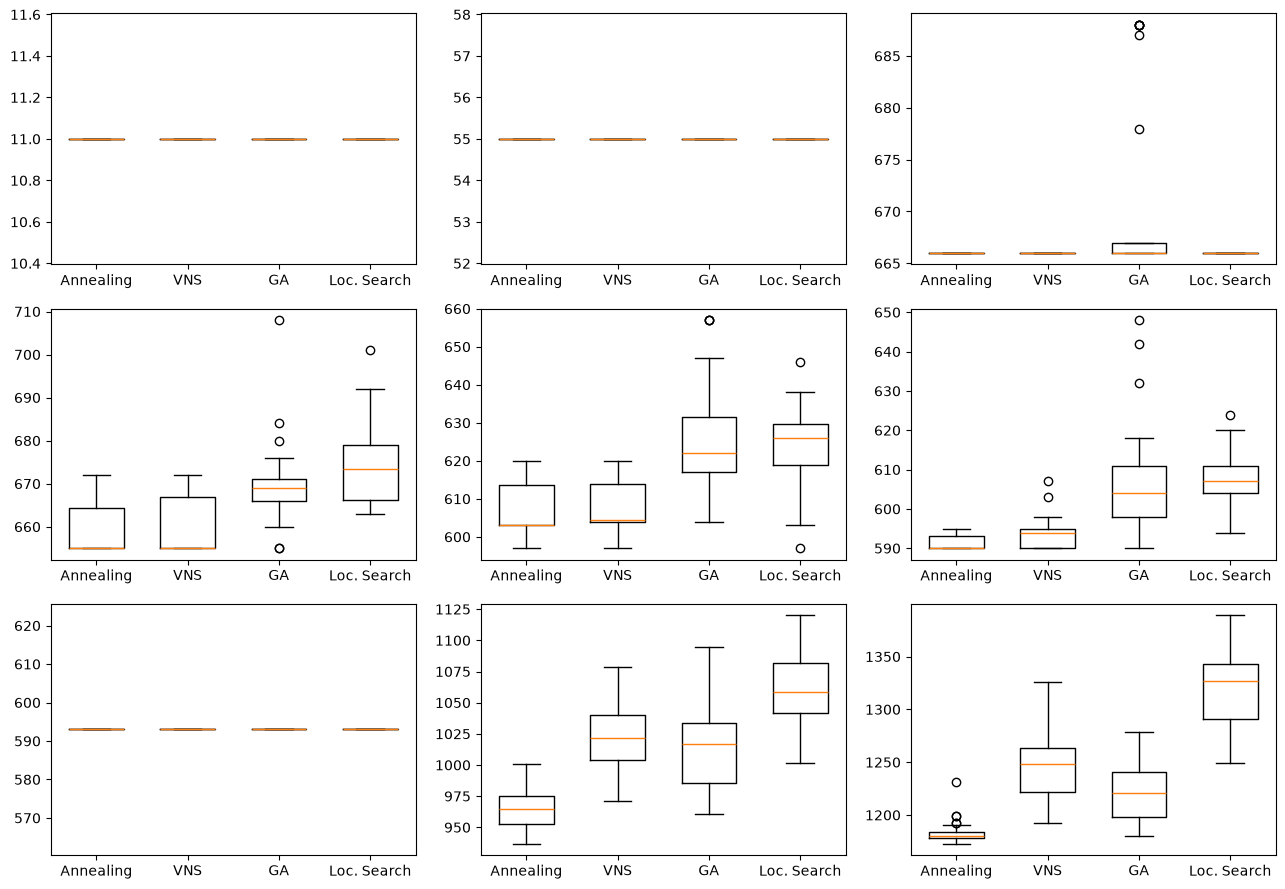

In [ ]:
fig, axes = plt.subplots(3,3,figsize=(13,9))
for ax, inst in zip(axes.ravel(), PROBLEMS):
    d = df[df.instance == inst]

    ax.boxplot([d[d.method == m].makespan for m in METHODS],
               tick_labels=METHODS, widths=0.6)

    opt = d.optimum.iloc[0]
    lb = d.lower_bound.iloc[0]

    if 0 < (opt - lb) / opt < 0.10:
        ax.axhline(lb, ls=":", c="0.5", lw=1, label=f"LB {lb}")


plt.tight_layout()

In [ ]:
?axes.ravel

Signature: axes.ravel(order='C')
Docstring:
a.ravel(order='C')

Return a flattened array.

Refer to `numpy.ravel` for full documentation.

See Also
--------
numpy.ravel : equivalent function
ndarray.flat : a flat iterator on the array.
Type:      builtin_function_or_method